In [18]:
from birdnet_analyzer.audio import open_audio_file, get_audio_file_length, get_sample_rate, save_signal, split_signal
from birdnet_analyzer.utils import collect_audio_files, list_subdirectories
import os

data = "D:/Acoustics/AnuraSET/raw_data/raw_data/"
for directory in list_subdirectories("D:/Acoustics/AnuraSET/raw_data/raw_data/"):
    print(directory)
    for audio_file in collect_audio_files(data+directory):
        signal, sample_rate = open_audio_file(audio_file) #Automatically resamples to 48kHz
        length = get_audio_file_length(audio_file)
        shards = split_signal(signal, sample_rate, 3.0, 2.0, 3.0)
        audio_file = os.path.basename(audio_file)
        audio_file = audio_file.replace(".wav", "_shard_")
        for i, shard in enumerate(shards, start=1):
            save_signal(shard, "D:\\Acoustics\\AnuraSet_3sec\\" + directory + "\\" + audio_file + str(i) + ".wav", sample_rate)



INCT17
['INCT17_20191113_040000.wav', 'INCT17_20191125_040000.wav', 'INCT17_20191126_040000.wav', 'INCT17_20191201_171500.wav', 'INCT17_20191205_004500.wav', 'INCT17_20191205_181500.wav', 'INCT17_20191205_191500.wav', 'INCT17_20191205_201500.wav', 'INCT17_20191205_211500.wav', 'INCT17_20191205_221500.wav', 'INCT17_20191205_231500.wav', 'INCT17_20191206_013000.wav', 'INCT17_20191206_174500.wav', 'INCT17_20191207_021500.wav', 'INCT17_20191207_031500.wav', 'INCT17_20191209_174500.wav', 'INCT17_20191215_184500.wav', 'INCT17_20191215_194500.wav', 'INCT17_20191215_204500.wav', 'INCT17_20191215_214500.wav', 'INCT17_20191215_224500.wav', 'INCT17_20191215_234500.wav', 'INCT17_20191216_001500.wav', 'INCT17_20191217_010000.wav', 'INCT17_20191217_024500.wav', 'INCT17_20191217_034500.wav', 'INCT17_20191217_183000.wav', 'INCT17_20191217_193000.wav', 'INCT17_20191217_203000.wav', 'INCT17_20191217_213000.wav', 'INCT17_20191217_223000.wav', 'INCT17_20191217_233000.wav', 'INCT17_20191218_000000.wav', 'I

KeyboardInterrupt: 

In [ ]:
import practice.audioutils as audioutils

audioutils.upsample_wav("D:/Acoustics/AnuraSET/raw_data/raw_data/INCT4/INCT4_20191005_173000.wav", 
                        "D:/Acoustics/AnuraSet_3sec/INCT4_20191005_173000_upsampled.wav",
                        48000)

Unexpected error: Error opening 'D:/Acoustics/AnuraSet_3sec/INCT4/INCT4_20191005_173000_upsampled.wav': System error.


In [30]:
directory = r"D:\Acoustics\AnuraSET\strong_labels"
import os
import pandas as pd

expected_cols = ["start", "end", "species"]
dfs = []

for root, _, flist in os.walk(directory):
    for f in flist:
        if not f.endswith(".txt"):
            continue

        label_file_path = os.path.join(root, f)
        try:
            new_df = pd.read_csv(label_file_path, sep="\t", names=expected_cols)
        except pd.errors.EmptyDataError:
            continue
        except Exception:
            continue

        if new_df.empty:
            continue

        dfs.append(new_df)

if dfs:
    df = pd.concat(dfs, ignore_index=True)
else:
    df = pd.DataFrame(columns=expected_cols)

df

,start,end,species
0,0.000000,59.988753,PHYSAU_M
1,9.960731,10.344517,LEPFUS_M
2,13.113683,13.302624,PITAZU_L
3,15.422305,15.564011,PITAZU_L
4,17.140487,17.229053,PITAZU_L
...,...,...,...
15995,19.130272,20.405623,BOAALB_L
15996,26.215557,28.955201,BOAALB_L
15997,32.875726,36.040487,BOAALB_L
15998,38.307778,46.337769,BOAALB_L


In [31]:
df["length"] = df["end"] - df["start"]
df

,start,end,species,length
0,0.000000,59.988753,PHYSAU_M,59.988753
1,9.960731,10.344517,LEPFUS_M,0.383786
2,13.113683,13.302624,PITAZU_L,0.188941
3,15.422305,15.564011,PITAZU_L,0.141706
4,17.140487,17.229053,PITAZU_L,0.088566
...,...,...,...,...
15995,19.130272,20.405623,BOAALB_L,1.275351
15996,26.215557,28.955201,BOAALB_L,2.739644
15997,32.875726,36.040487,BOAALB_L,3.164761
15998,38.307778,46.337769,BOAALB_L,8.029991


start      2835
end        2835
species    2835
length     2835
dtype: int64

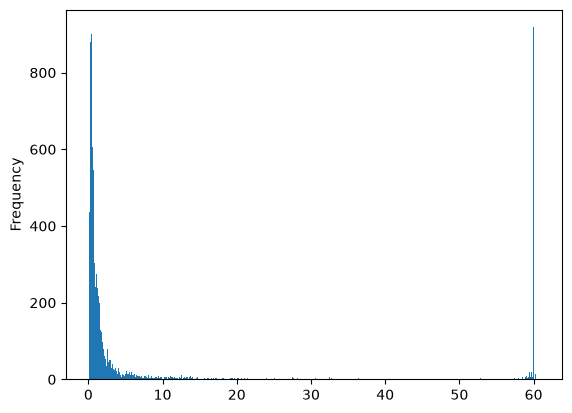

In [41]:
df["length"].plot.hist(bins=1000)
df["length"].describe()
df[df["length"] > 5].count()


In [5]:
import pandas as pd
species_path = "./specieslist.csv"

df = pd.read_csv(species_path, sep=";")
df = df.loc[df["display"] == 1]

# for species in list(df["scientific_name"]):
#     print(type(species))

df
#for species in df["scientific_name"]:

,scientific_name,display
24,Phyllobates vittatus,1.0
28,Boana rosenbergi,1.0
29,Dendropsophus ebraccatus,1.0
30,Dendropsophus microcephalus,1.0
31,Scinax boulengeri,1.0
39,Engystomops pustulosus,1.0
49,Agalychnis callidryas,1.0
50,Agalychnis spurrelli,1.0


In [1]:
import os

def lowercase_png_extensions(directory=r"C:\OsaAnurans\docs\img"):
    for filename in os.listdir(directory):
        if filename.endswith(".PNG"):
            old_path = os.path.join(directory, filename)
            new_path = os.path.join(directory, filename[:-4] + ".png")
            os.rename(old_path, new_path)
            print(f"Renamed: {filename} -> {os.path.basename(new_path)}")

# Run the function in the current directory
lowercase_png_extensions()

Renamed: Agalychnis callidryas.PNG -> Agalychnis callidryas.png
Renamed: Agalychnis spurrelli.PNG -> Agalychnis spurrelli.png
Renamed: Allobates talamancae.PNG -> Allobates talamancae.png
Renamed: Boana rosenbergi.PNG -> Boana rosenbergi.png
Renamed: Cochranella granulosa.PNG -> Cochranella granulosa.png
Renamed: Dendrobates auratus.PNG -> Dendrobates auratus.png
Renamed: Dendropsophus ebraccatus.PNG -> Dendropsophus ebraccatus.png
Renamed: Dendropsophus microcephalus.PNG -> Dendropsophus microcephalus.png
Renamed: Diasporus diastema.PNG -> Diasporus diastema.png
Renamed: Engystomops pustulosus.PNG -> Engystomops pustulosus.png
Renamed: Espadarana prosoblepon.PNG -> Espadarana prosoblepon.png
Renamed: Hyalinobatrachium colymbiphyllum.PNG -> Hyalinobatrachium colymbiphyllum.png
Renamed: Incilius aucoinae.PNG -> Incilius aucoinae.png
Renamed: Leptodactylus fragilis.PNG -> Leptodactylus fragilis.png
Renamed: Leptodactylus insularum.PNG -> Leptodactylus insularum.png
Renamed: Leptodactylus

In [6]:
from pydub import AudioSegment


import os

def wav_to_mp3(directory=r"C:\OsaAnurans\docs\audio"):
    for filename in os.listdir(directory):
        if filename.endswith(".wav"):
            old_path = os.path.join(directory, filename)
            print(old_path)
            new_path = os.path.join(directory, filename[:-4] + ".mp3")
            print(new_path)
            AudioSegment.from_wav(old_path).export(new_path, format="mp3")
            
            print(f"converted: {filename} -> {os.path.basename(new_path)}")

# Run the function in the current directory
wav_to_mp3()

C:\OsaAnurans\docs\audio\Agalychnis callidryas.wav
C:\OsaAnurans\docs\audio\Agalychnis callidryas.mp3


FileNotFoundError: [WinError 2] El sistema no puede encontrar el archivo especificado

In [1]:
from pydub import AudioSegment




AudioSegment.from_wav(r"C:\OsaAnurans\docs\audio\Agalychnis callidryas.wav").export(r"C:\OsaAnurans\docs\audio\Agalychnis callidryas.mp3", format="mp3")
            


c:\OsaAnurans\.venv\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)
c:\OsaAnurans\.venv\Lib\site-packages\pydub\utils.py:198: RuntimeWarning: Couldn't find ffprobe or avprobe - defaulting to ffprobe, but may not work
  warn("Couldn't find ffprobe or avprobe - defaulting to ffprobe, but may not work", RuntimeWarning)
c:\OsaAnurans\.venv\Lib\site-packages\pydub\utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
c:\OsaAnurans\.venv\Lib\site-packages\pydub\utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
c:\OsaAnurans\.venv\Lib\site-packages\pydub\utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
c:\OsaAnurans\.ven

FileNotFoundError: [WinError 2] El sistema no puede encontrar el archivo especificado

In [8]:
import os
import pandas as pd

species_path = "../specieslist.csv"

df = pd.read_csv(species_path, sep="\t")
df = df.loc[df["display"] == 1]

for species in list(df["scientific_name"]):
    try:
        os.mkdir(r"C:\OsaAnurans\docs\static" + f"/{species}")
        os.mkdir(r"C:\OsaAnurans\docs\static" + f"/{species}/audio")
        os.mkdir(r"C:\OsaAnurans\docs\static" + f"/{species}/img")
        os.mkdir(r"C:\OsaAnurans\docs\static" + f"/{species}/img/spec")
    except FileExistsError:
        print("Directories for " + species + " already exists")

Directories for Agalychnis callidryas already exists
Directories for Agalychnis spurrelli already exists
Directories for Boana rosenbergi already exists
Directories for Dendropsophus ebraccatus already exists
Directories for Dendropsophus microcephalus already exists
Directories for Engystomops pustulosus already exists
Directories for Leptodactylus fragilis already exists
Directories for Leptodactylus insularum already exists
Directories for Leptodactylus savagei already exists
Directories for Phyllobates vittatus already exists
Directories for Scinax boulengeri already exists


In [6]:
import pandas as pd

df = pd.read_excel(r"C:\OsaAnurans\Costa Rican Amphibians.xlsx")
df.to_csv(r"C:\OsaAnurans\specieslist.csv", sep="\t", index=False)

In [49]:
import pandas as pd
from pathlib import Path

species_path = "../specieslist.csv"

df = pd.read_csv(species_path, sep="\t")

df["audio_files"] = ""
df["spec_files"] = ""

directory=r"C:\OsaAnurans\docs\static"

directory = Path(directory)

# for filename in list(directory.rglob("*")):
#     if filename.is_file():
#         old_path = directory / filename
#         print(filename)
        # new_path = old_path.with_name(f"{old_path.stem}0{old_path.suffix}")
        # print(new_path)
        # old_path.rename(new_path)

# print(df["audio_files"])

species = [x for x in directory.iterdir() if x.is_dir()]


for specie in species:
    specie_name = specie.stem
    index = df["scientific_name"].eq(specie_name).idxmax()
    audio_files = []
    spec_files = []

    spec_path = specie / "img/spec"



    for filename in specie.rglob("*.mp3"):
        audio_files.append(filename.name)

    for filename in spec_path.rglob("*.webp"):
        spec_files.append(filename.name)

    

    df.at[index, "audio_files"] = ",".join(audio_files)
    df.at[index, "spec_files"] = ",".join(spec_files)




df.to_csv(r"C:\OsaAnurans\specieslist.csv", sep="\t", index=False)
df["spec_files"]

0                                                      
1     Agalychnis callidryas.webp,Agalychnis callidry...
2                            Agalychnis spurrelli0.webp
3                                                      
4                                                      
5                                Boana rosenbergi0.webp
6                                                      
7                                                      
8                                                      
9                                                      
10                                                     
11                                                     
12                                                     
13                                                     
14                       Dendropsophus ebraccatus0.webp
15                    Dendropsophus microcephalus0.webp
16                                                     
17                                              

C:\OsaAnurans\docs\static\Agalychnis callidryas\audio\Agalychnis callidryas.mp3
C:\OsaAnurans\docs\static\Agalychnis callidryas\audio\Agalychnis callidryas0.mp3
C:\OsaAnurans\docs\static\Agalychnis spurrelli\audio\Agalychnis spurrelli0.mp3
C:\OsaAnurans\docs\static\Boana rosenbergi\audio\Boana rosenbergi0.mp3
C:\OsaAnurans\docs\static\Dendropsophus ebraccatus\audio\Dendropsophus ebraccatus0.mp3
C:\OsaAnurans\docs\static\Dendropsophus microcephalus\audio\Dendropsophus microcephalus0.mp3
C:\OsaAnurans\docs\static\Engystomops pustulosus\audio\Engystomops pustulosus0.mp3
C:\OsaAnurans\docs\static\Leptodactylus fragilis\audio\Leptodactylus fragilis0.mp3
C:\OsaAnurans\docs\static\Leptodactylus insularum\audio\Leptodactylus insularum0.mp3
C:\OsaAnurans\docs\static\Leptodactylus savagei\audio\Leptodactylus savagei0.mp3
C:\OsaAnurans\docs\static\Phyllobates vittatus\audio\Phyllobates vittatus0.mp3
C:\OsaAnurans\docs\static\Scinax boulengeri\audio\Scinax boulengeri0.mp3


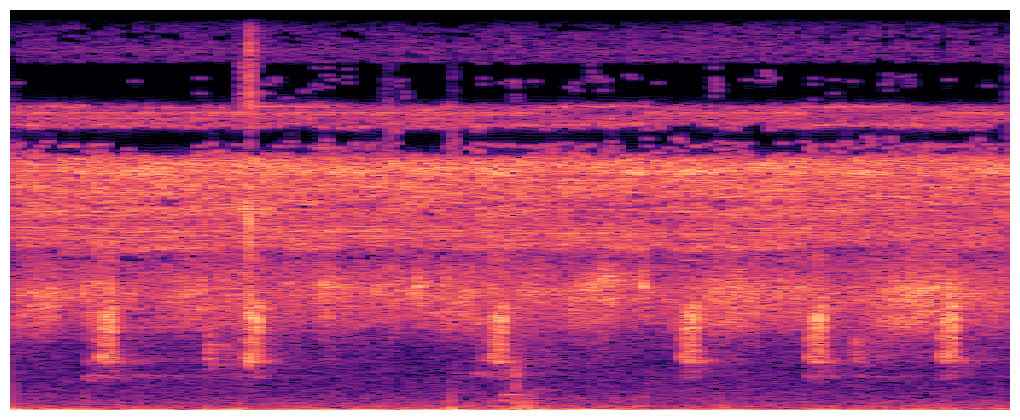

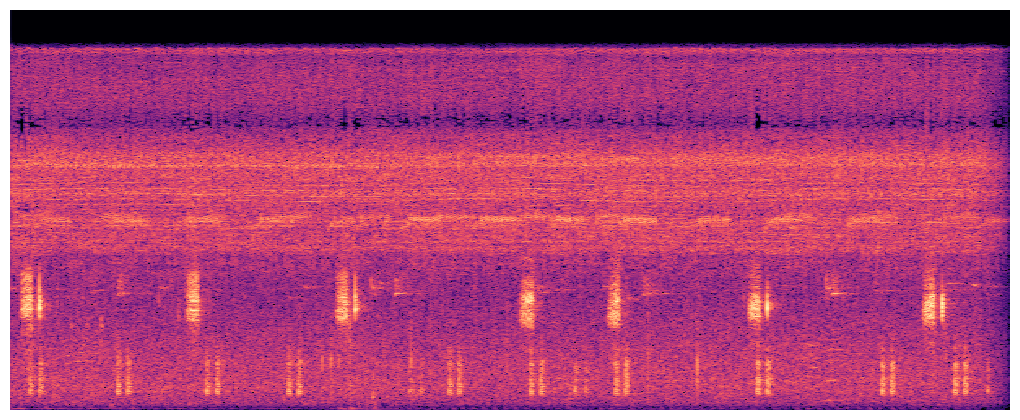

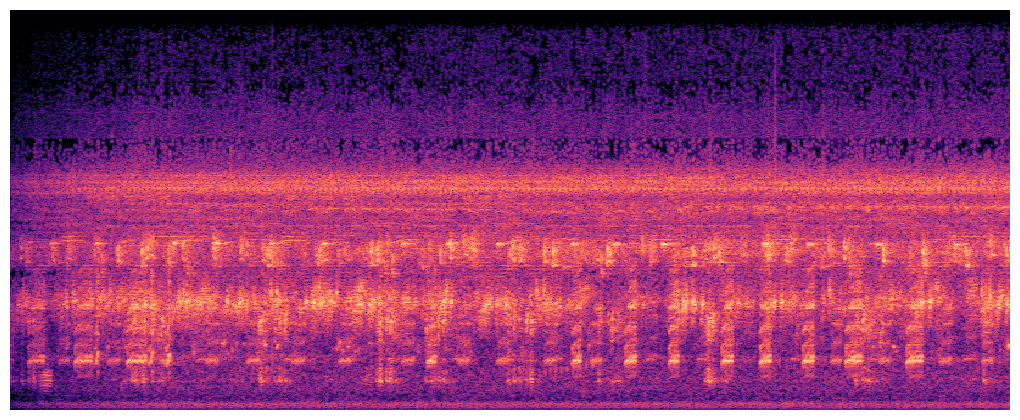

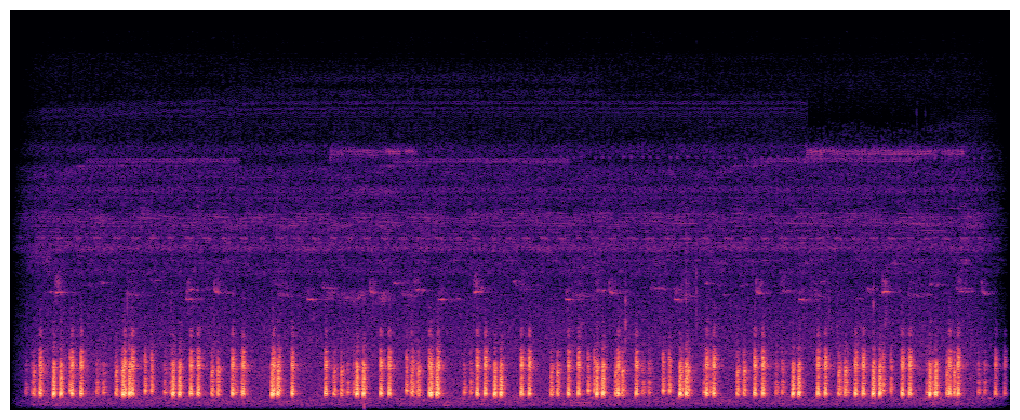

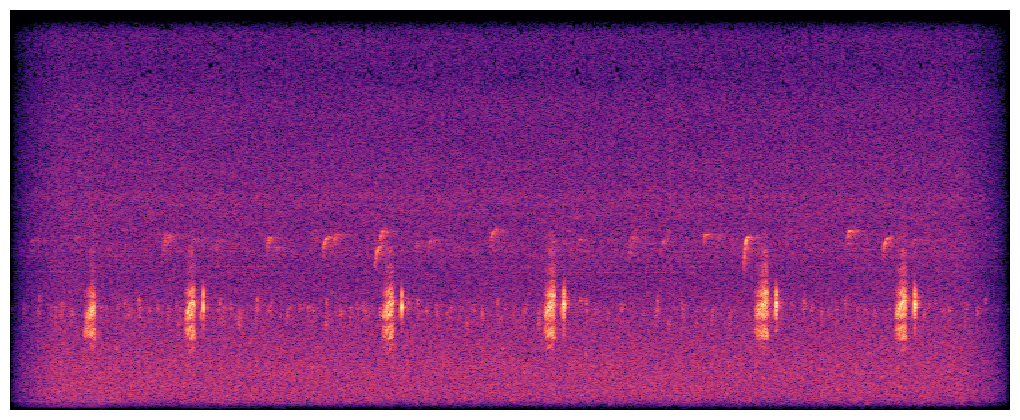

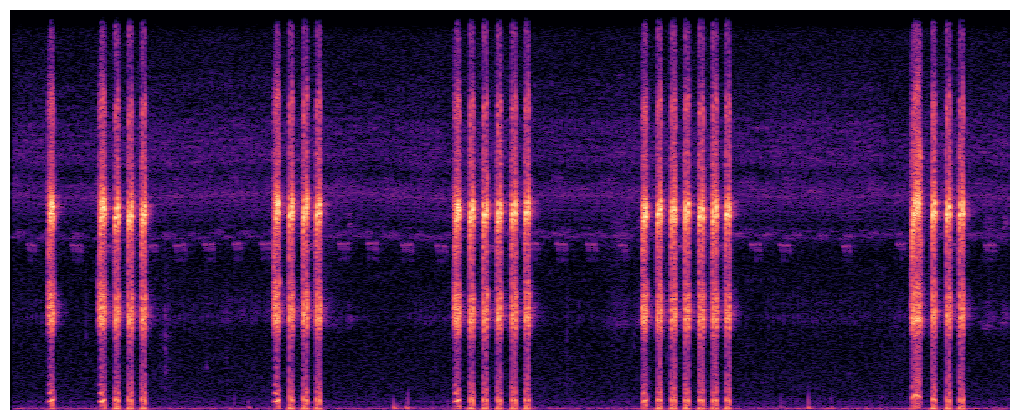

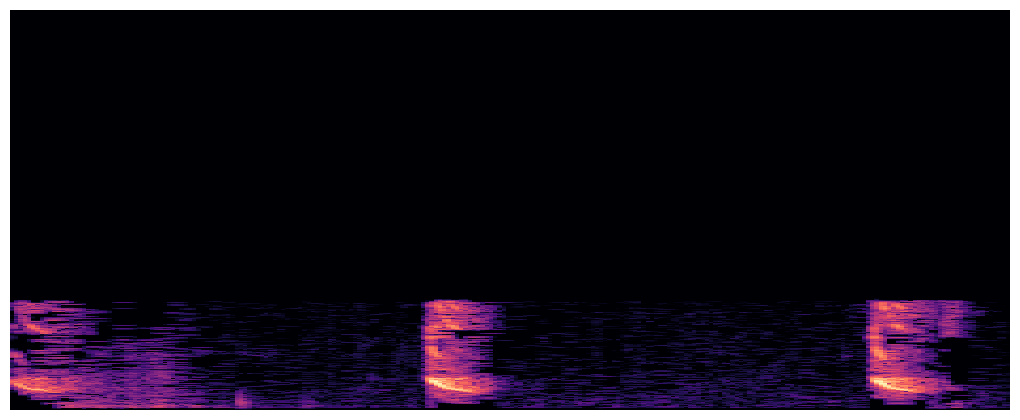

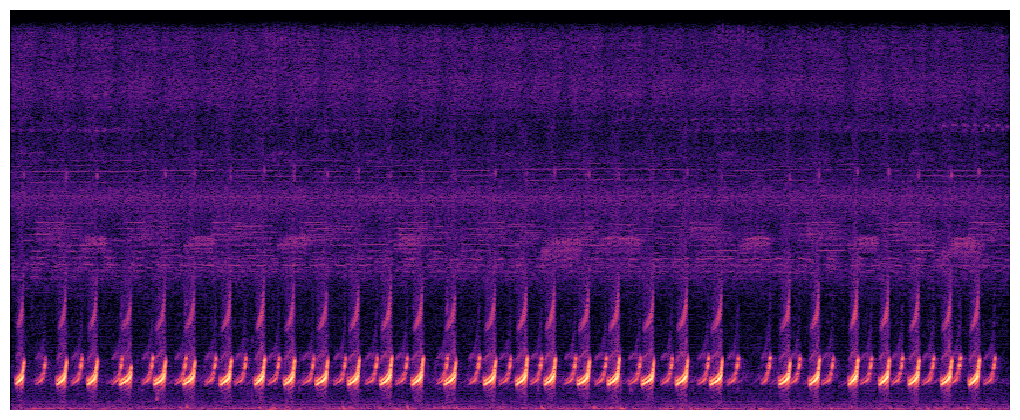

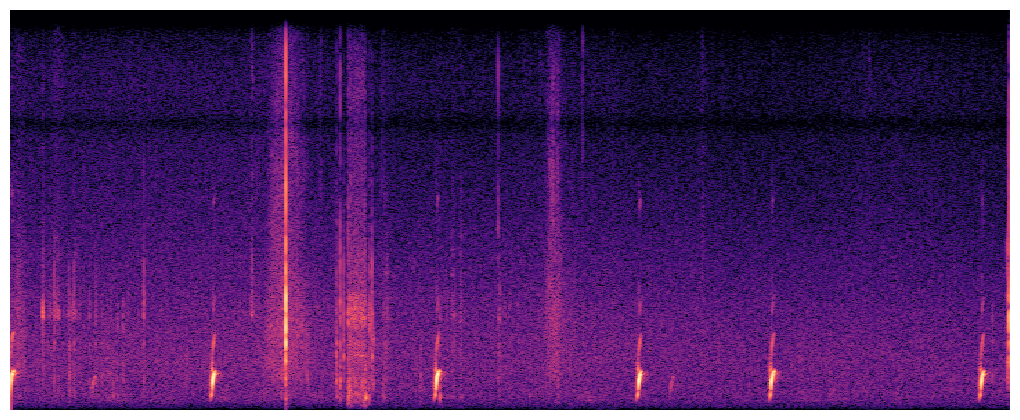

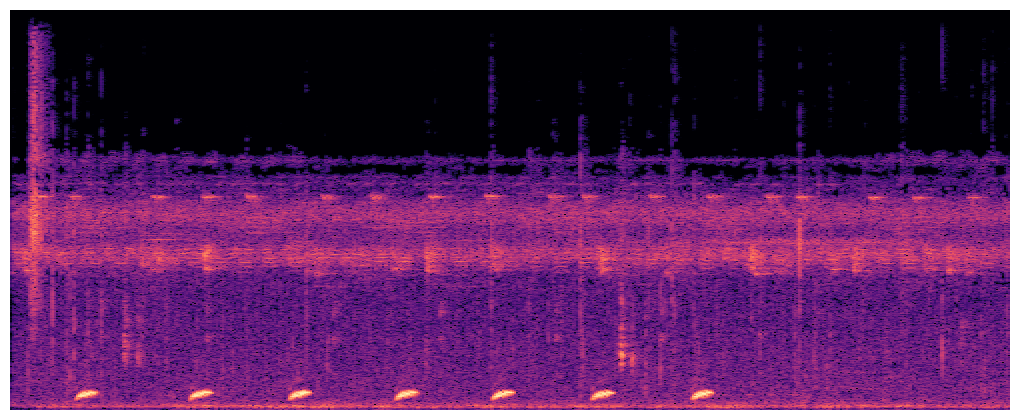

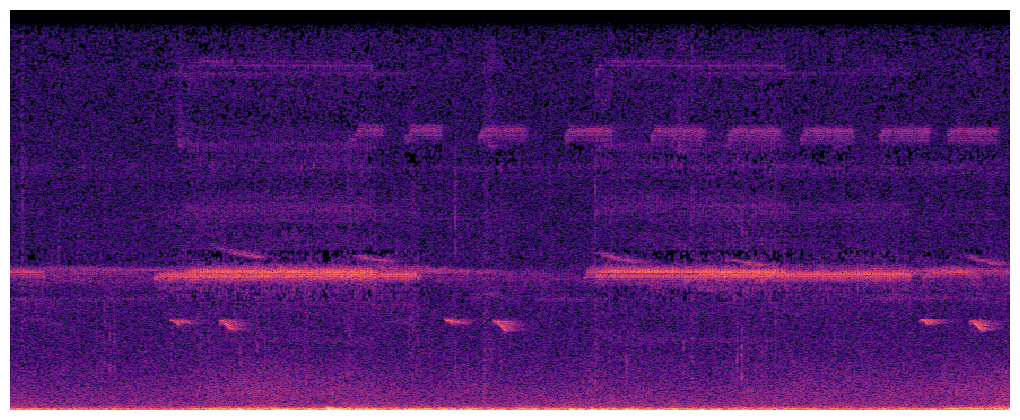

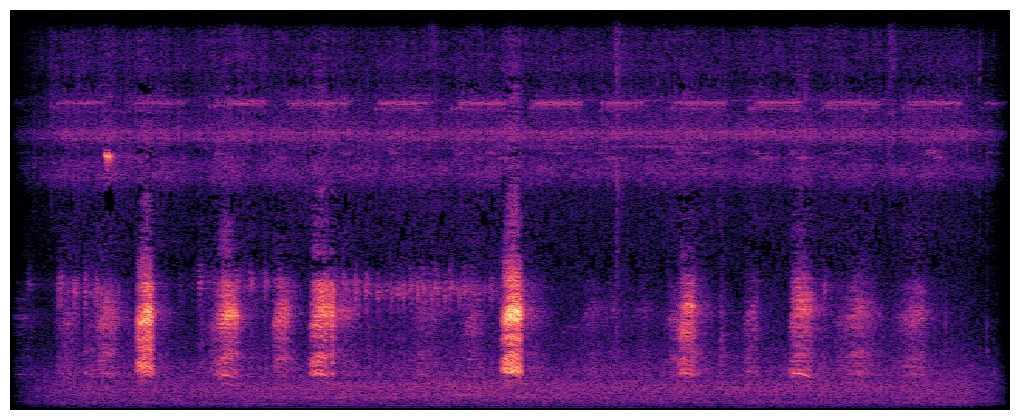

In [48]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# species_path = "../specieslist.csv"

# df = pd.read_csv(species_path, sep="\t")


directory=r"C:\OsaAnurans\docs\static"

directory = Path(directory)

species = [x for x in directory.iterdir() if x.is_dir()]

for specie in species:
    for filename in specie.rglob("*.mp3"):
        spec_path = specie / "img/spec" / filename.name
        spec_path = spec_path.with_suffix(".webp")

        print(filename)

        y,sr = librosa.load(filename)
        D = librosa.stft(y)

        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)


        fig, ax = plt.subplots(figsize=(10,4))
        fig.patch.set_visible(False)
        ax.axis("off")
        librosa.display.specshow(S_db, sr=sr)
        plt.subplots_adjust(top=1, bottom=0, left=0, right=1, hspace=0, wspace=0)
        plt.savefig(spec_path, transparent=True, bbox_inches="tight", pad_inches=0, format="webp")


    